In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

import os

In [3]:
dataset_dir = "dataset"

In [4]:
csv_tables = [
    "application_train.csv",
    "bureau_balance.csv",
    "bureau.csv",
    "credit_card_balance.csv",
    "installments_payments.csv",
    "POS_CASH_balance.csv",
    "previous_application.csv",
    "sample_submission.csv"
]
        
(
    applications_df,
    bureau_balance_df,
    bureau_df,
    credit_card_balance_df,
    installments_payments_df,
    POS_CASH_balance_df,
    previous_application_df,
    sample_submission_df
) = [pd.read_csv(os.path.join(dataset_dir, table)) for table in csv_tables]

## Exploratory Data Analysis (EDA)
In this section, we will examine the main data table *application_train.csv*.

We are dealing with an imbalanced class problem.

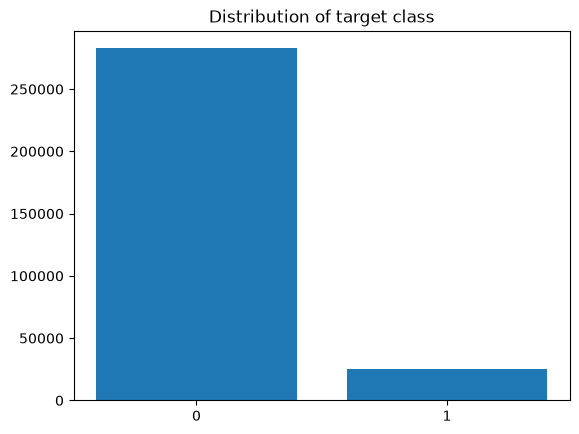

In [5]:
target_counts = applications_df["TARGET"].value_counts().tolist()

plt.bar([0, 1], target_counts)
plt.xticks([0, 1])
plt.title("Distribution of target class")
plt.show()

In [6]:
def missing_values(df):
    missing_count = df.isna().sum()
    missing_percentage = missing_count / len(df) * 100

    missing_df = pd.concat([missing_count, missing_percentage], axis=1)
    missing_df.columns=["Missing Values", "Missing Values (%)"]
    missing_df = missing_df.sort_values(by="Missing Values (%)", ascending=False)
    
    return missing_df

In [7]:
missing_values(applications_df).head(20)

,Missing Values,Missing Values (%)
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_MEDI,214865,69.872297
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


In [8]:
applications_df.dtypes.value_counts()

float64    65
int64      41
str        16
Name: count, dtype: int64

In [9]:
applications_df["DAYS_EMPLOYED"].sort_values().value_counts()

DAYS_EMPLOYED
 365243    55374
-200         156
-224         152
-230         151
-199         151
           ...  
-23            1
-10            1
-7             1
-5             1
-1             1
Name: count, Length: 12574, dtype: int64

In [10]:
applications_df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


## Feature engineering

The `agg_numeric_columns` function creates a new DataFrame with aggregated numeric columns of the given DataFrame.

In [18]:
def agg_numeric_columns(df, groupby_columns, metrics=["count", "mean", "sum", "min", "max"], exclude_columns=[]):
    # Find all numeric columns that are not used for grouping
    numeric_columns = df.select_dtypes(include="number").columns.tolist()
    numeric_columns = [c for c in numeric_columns if c not in groupby_columns and c not in exclude_columns]

    # Compute the aggregations and return a multi-index DataFrame
    multi_index_agg = df.groupby(groupby_columns)[numeric_columns].agg(metrics)

    # Flatten the DataFrame
    agg_df = pd.DataFrame({
        f"{column}_{agg.upper()}": multi_index_agg[(column, agg)]
        for column, agg in multi_index_agg.columns
    }).reset_index()

    # Replace NaN values with 0
    agg_df = agg_df.fillna(0)

    return agg_df

In [19]:
agg_numeric_columns(bureau_df, groupby_columns=["SK_ID_CURR"], exclude_columns=["SK_ID_BUREAU"])

,SK_ID_CURR,DAYS_CREDIT_COUNT,DAYS_CREDIT_MEAN,DAYS_CREDIT_SUM,DAYS_CREDIT_MIN,DAYS_CREDIT_MAX,CREDIT_DAY_OVERDUE_COUNT,CREDIT_DAY_OVERDUE_MEAN,CREDIT_DAY_OVERDUE_SUM,CREDIT_DAY_OVERDUE_MIN,...,DAYS_CREDIT_UPDATE_COUNT,DAYS_CREDIT_UPDATE_MEAN,DAYS_CREDIT_UPDATE_SUM,DAYS_CREDIT_UPDATE_MIN,DAYS_CREDIT_UPDATE_MAX,AMT_ANNUITY_COUNT,AMT_ANNUITY_MEAN,AMT_ANNUITY_SUM,AMT_ANNUITY_MIN,AMT_ANNUITY_MAX
0,100001,7,-735.000000,-5145,-1572,-49,7,0.0,0,0,...,7,-93.142857,-652,-155,-6,7,3545.357143,24817.500,0.000,10822.5
1,100002,8,-874.000000,-6992,-1437,-103,8,0.0,0,0,...,8,-499.875000,-3999,-1185,-7,7,0.000000,0.000,0.000,0.0
2,100003,4,-1400.750000,-5603,-2586,-606,4,0.0,0,0,...,4,-816.000000,-3264,-2131,-43,0,0.000000,0.000,0.000,0.0
3,100004,2,-867.000000,-1734,-1326,-408,2,0.0,0,0,...,2,-532.000000,-1064,-682,-382,0,0.000000,0.000,0.000,0.0
4,100005,3,-190.666667,-572,-373,-62,3,0.0,0,0,...,3,-54.333333,-163,-121,-11,3,1420.500000,4261.500,0.000,4261.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305806,456249,13,-1667.076923,-21672,-2713,-483,13,0.0,0,0,...,13,-1064.538462,-13839,-2498,-12,0,0.000000,0.000,0.000,0.0
305807,456250,3,-862.000000,-2586,-1002,-760,3,0.0,0,0,...,3,-60.333333,-181,-127,-23,3,154567.965000,463703.895,27757.395,384147.0
305808,456253,4,-867.500000,-3470,-919,-713,4,0.0,0,0,...,4,-253.250000,-1013,-701,-5,3,58369.500000,175108.500,58369.500,58369.5
305809,456254,1,-1104.000000,-1104,-1104,-1104,1,0.0,0,0,...,1,-401.000000,-401,-401,-401,1,0.000000,0.000,0.000,0.0


The `agg_categorical_columns` function creates a new DataFrame with aggregated categorical
columns of the given DataFrame.

In [21]:
def agg_categorical_columns(df, groupby_columns, exclude_columns=[]):
    # Find all categorical columns that are not used for grouping
    categorical_columns = df.select_dtypes(include="str").columns.tolist()
    categorical_columns = [
        c for c in categorical_columns
        if c not in groupby_columns and c not in exclude_columns
    ]

    agg_df = df[groupby_columns].drop_duplicates()

    for column in categorical_columns:
        agg_column_df = (
            df
                .groupby(groupby_columns)[column]
                .value_counts()
                .unstack(fill_value=0)
                .add_prefix(f"{column}_")
                .reset_index()
                .rename_axis(None, axis=1)
        )
        agg_column_df.columns = agg_column_df.columns.str.upper()
        agg_df = pd.merge(agg_df, agg_column_df, on=groupby_columns)
        
    return agg_df

In [22]:
agg_categorical_columns(bureau_df, groupby_columns=["SK_ID_CURR"])

,SK_ID_CURR,CREDIT_ACTIVE_ACTIVE,CREDIT_ACTIVE_BAD DEBT,CREDIT_ACTIVE_CLOSED,CREDIT_ACTIVE_SOLD,CREDIT_CURRENCY_CURRENCY 1,CREDIT_CURRENCY_CURRENCY 2,CREDIT_CURRENCY_CURRENCY 3,CREDIT_CURRENCY_CURRENCY 4,CREDIT_TYPE_ANOTHER TYPE OF LOAN,...,CREDIT_TYPE_INTERBANK CREDIT,CREDIT_TYPE_LOAN FOR BUSINESS DEVELOPMENT,CREDIT_TYPE_LOAN FOR PURCHASE OF SHARES (MARGIN LENDING),CREDIT_TYPE_LOAN FOR THE PURCHASE OF EQUIPMENT,CREDIT_TYPE_LOAN FOR WORKING CAPITAL REPLENISHMENT,CREDIT_TYPE_MICROLOAN,CREDIT_TYPE_MOBILE OPERATOR LOAN,CREDIT_TYPE_MORTGAGE,CREDIT_TYPE_REAL ESTATE LOAN,CREDIT_TYPE_UNKNOWN TYPE OF LOAN
0,215354,6,0,5,0,11,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,162297,3,0,3,0,6,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,402440,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,238881,3,0,5,0,8,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,222183,5,0,3,0,8,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305806,207190,0,0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
305807,324956,0,0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
305808,448157,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
305809,345866,0,0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
